In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.cluster import MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.neighbors import NearestNeighbors

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Recarregando os dados para garantir a integridade
data_path = '../../data/raw/UNSW-NB15'

df_train = pd.read_csv(os.path.join(data_path, 'UNSW_NB15_training-set.csv'))
df_test = pd.read_csv(os.path.join(data_path, 'UNSW_NB15_testing-set.csv'))

df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)
df_train['service'] = df_train['service'].replace('-', 'unknown')
df_test['service'] = df_test['service'].replace('-', 'unknown')

# Filtrar o conjunto de treino para conter APENAS o tráfego normal
df_train_normal = df_train[df_train['label'] == 0]
X_train_normal = df_train_normal.drop(['attack_cat', 'label'], axis=1)

# Preparar o conjunto de teste completo
X_test = df_test.drop(['attack_cat', 'label'], axis=1)
y_test = df_test['label'] # Rótulos verdadeiros para avaliação

# Definir e ajustar o pré-processador nos dados normais
numeric_features = X_train_normal.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train_normal.select_dtypes(include=['object']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
print("Ajustando o pré-processador...")
preprocessor.fit(X_train_normal)

# Transformar os dados de treino e teste
print("Transformando os dados...")
X_train_normal_processed = preprocessor.transform(X_train_normal)
X_test_processed = preprocessor.transform(X_test)

print("Dados pré-processados e prontos.")

Ajustando o pré-processador...
Transformando os dados...
Dados pré-processados e prontos.


In [3]:
# Definindo o espaço de busca para os hiperparâmetros
k_range = [1, 2, 3, 5, 8]
percentile_range = [90, 95, 97, 99]

# Variáveis para armazenar os melhores resultados
best_score = -1
best_k = 0
best_percentile = 0

print("Iniciando a busca em grade (Grid Search) por k e pelo limiar de percentil...")

# Loop para a busca
for k in k_range:
    for p in percentile_range:
        # Treinar o modelo com a configuração atual
        mbk = MiniBatchKMeans(n_clusters=k, random_state=42, n_init='auto', batch_size=2048)
        mbk.fit(X_train_normal_processed)
        
        # Calcular o limiar
        distances_train = mbk.transform(X_train_normal_processed)
        # Para k > 1, pegamos a distância mínima para o centroide mais próximo
        min_distances_train = np.min(distances_train, axis=1)
        threshold = np.percentile(min_distances_train, p)
        
        # Fazer previsões no conjunto de teste
        distances_test = mbk.transform(X_test_processed)
        min_distances_test = np.min(distances_test, axis=1)
        y_pred = np.where(min_distances_test > threshold, 1, 0)
        
        # Calcular o F1-score para a classe de ataque (label=1)
        score = f1_score(y_test, y_pred, pos_label=1)
        
        # Verificar se é o melhor resultado até agora
        if score > best_score:
            best_score = score
            best_k = k
            best_percentile = p
            print(f"  Novo melhor resultado! k={k}, Percentil={p} -> F1-Score (Ataque): {score:.4f}")

print("\nBusca em grade concluída!")
print(f"Melhor F1-Score para a classe 'Ataque': {best_score:.4f}")
print(f"Melhor k (n_clusters): {best_k}")
print(f"Melhor Percentil: {best_percentile}")

Iniciando a busca em grade (Grid Search) por k e pelo limiar de percentil...
  Novo melhor resultado! k=1, Percentil=90 -> F1-Score (Ataque): 0.4416
  Novo melhor resultado! k=2, Percentil=90 -> F1-Score (Ataque): 0.4434
  Novo melhor resultado! k=3, Percentil=90 -> F1-Score (Ataque): 0.4481
  Novo melhor resultado! k=5, Percentil=90 -> F1-Score (Ataque): 0.5169

Busca em grade concluída!
Melhor F1-Score para a classe 'Ataque': 0.5169
Melhor k (n_clusters): 5
Melhor Percentil: 90


--- Avaliação Final com os Melhores Parâmetros Encontrados ---
Treinando e avaliando com k=5 e limiar do percentil 90% (Threshold: 6.22)

--- Relatório de Classificação Binária (MiniBatchKMeans Otimizado) ---
              precision    recall  f1-score   support

  Normal (0)       0.53      0.83      0.65     37000
  Ataque (1)       0.74      0.40      0.52     45332

    accuracy                           0.59     82332
   macro avg       0.64      0.61      0.58     82332
weighted avg       0.65      0.59      0.58     82332



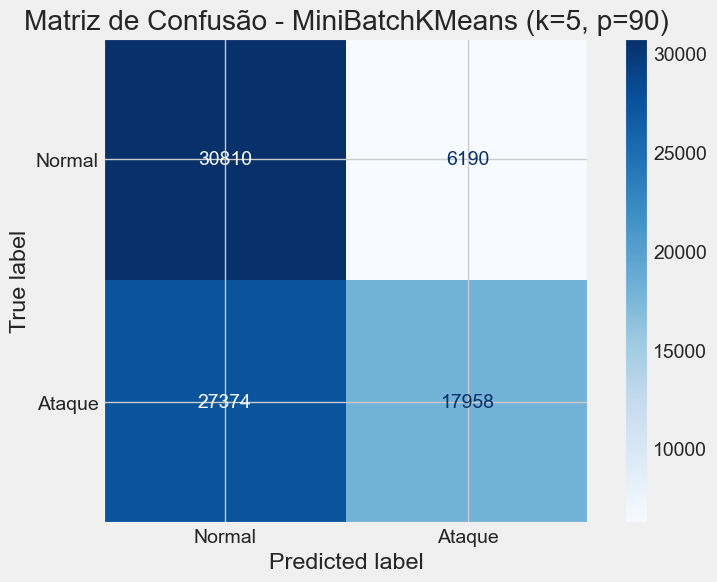

In [4]:
print("--- Avaliação Final com os Melhores Parâmetros Encontrados ---")

# Treinar o modelo final com o melhor k
final_mbk = MiniBatchKMeans(n_clusters=best_k, random_state=42, n_init='auto', batch_size=2048)
final_mbk.fit(X_train_normal_processed)

# Calcular o limiar final com o melhor percentil
distances_train_final = final_mbk.transform(X_train_normal_processed)
min_distances_train_final = np.min(distances_train_final, axis=1)
final_threshold = np.percentile(min_distances_train_final, best_percentile)

print(f"Treinando e avaliando com k={best_k} e limiar do percentil {best_percentile}% (Threshold: {final_threshold:.2f})")

# Fazer as previsões finais
distances_test_final = final_mbk.transform(X_test_processed)
min_distances_test_final = np.min(distances_test_final, axis=1)
y_pred_final = np.where(min_distances_test_final > final_threshold, 1, 0)

# Avaliar os resultados finais
print("\n--- Relatório de Classificação Binária (MiniBatchKMeans Otimizado) ---")
print(classification_report(y_test, y_pred_final, target_names=['Normal (0)', 'Ataque (1)']))

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Ataque'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title(f'Matriz de Confusão - MiniBatchKMeans (k={best_k}, p={best_percentile})')
plt.show()